# 02 - Dataset de preguntas de opcion multiple

Convierte el corpus limpio en las dos tablas que consume el resto del proyecto.

| Salida | Para que sirve |
|---|---|
| `data/chunks.parquet` | **la base de datos de la aplicacion**: todos los fragmentos aptos, sin preguntas |
| `data/muestra_api.parquet` | el subconjunto que pasa por la API para construir el set de entrenamiento |

La decision de alcance mas importante del proyecto esta en la seccion 2.3: **no**
se generan preguntas para todos los fragmentos. Solo una muestra pasa por la API,
y existe unicamente para entrenar. Los demas los cubre el modelo afinado cuando un
usuario los pida. Eso es lo que justifica el fine-tuning.

Secciones 2.1 a 2.3. La generacion con el LLM (2.4) viene despues.

## 0. Preparacion

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter

DATA = Path("../data")
SEMILLA = 42
pd.set_option("display.max_colwidth", 90)

clean = pd.read_parquet(DATA / "medqa_clean.parquet")
print(f"corpus limpio: {len(clean):,} filas, {clean['document_id'].nunique():,} documentos")
clean.head(2)

corpus limpio: 14,528 filas, 3,474 documentos


,document_id,document_source,document_url,category,question_id,question_focus,question_type,question,answer,answer_len,question_id_original,answer_is_generic,answer_needs_chunking
0,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair,NaN,GHR_0000559-1_0,keratoderma with woolly hair,information,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of related conditions that affect the skin and...,1921,0000559-1,False,True
1,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair,NaN,GHR_0000559-2_1,keratoderma with woolly hair,frequency,How many people are affected by keratoderma with woolly hair ?,Keratoderma with woolly hair is rare; its prevalence worldwide is unknown. Type I (Nax...,469,0000559-2,False,False


### Nota sobre `category`

El notebook 01 conserva la columna `category` pensando en usarla como dimension
de seleccion en la aplicacion. Conviene mirar si de verdad sirve antes de
apoyarse en ella.

In [2]:
print(clean["category"].value_counts(dropna=False).to_string())
pct_nulo = clean["category"].isna().mean() * 100
print(f"\nnulos: {pct_nulo:.0f}%")
print(f"question_type : {clean['question_type'].nunique()} valores")
print(f"question_focus: {clean['question_focus'].nunique():,} valores")

category
NaN        13661
Disease      572
Other        295

nulos: 94%
question_type : 16 valores
question_focus: 5,127 valores


**Conclusion:** `category` queda casi vacia despues de la limpieza, y la
categoria `Drug` -que era un tercio del dataset crudo- desaparece por completo.
No sirve como dimension de seleccion.

**El selector de la aplicacion se construye con `question_type` (16 valores, el
tipo de pregunta) y `question_focus` (miles de valores, la enfermedad concreta).**
La columna se conserva porque no molesta, pero no se depende de ella.

## 2.1 Fragmentacion

Se reutiliza la estrategia **B_512** del proyecto anterior: `chunk_size=512` con
`chunk_overlap=64`. La razon vale tambien para esta tarea aunque sea otra:
alrededor de 512 caracteres es un hecho medico completo, que es la unidad correcta
para formular **una** pregunta. Con fragmentos mas grandes el modelo tiene que
elegir arbitrariamente sobre que preguntar, y las preguntas salen vagas.

### Por que se mantiene el solape de 64

En el proyecto de RAG el solape servia para que un hecho partido por la frontera
apareciera entero en algun fragmento, y asi fuera recuperable. Aqui esa razon no
aplica, pero hay otra: **compensa el recorte de la seccion 2.2**.

Sin solape, la oracion que el troceado parte se pierde del todo: no esta al final
del fragmento anterior (recortado) ni al principio del siguiente (recortado
tambien). Medido sobre 1,200 respuestas:

| Estrategia | Aptos | Texto conservado | Casi-duplicados |
|---|---|---|---|
| **solape 64** | 2,926 | **72.7%** | 7 |
| sin solape | 2,675 | 67.0% | 5 |
| sin solape, cortando en oraciones | 3,015 | 66.0% | 5 |

El riesgo esperable del solape -preguntas casi identicas generadas desde dos
fragmentos que comparten texto- **no se materializa**: 7 pares en casi 3,000
fragmentos, igual que sin solape. La razon es que el recorte elimina justamente
la zona solapada, que es el final de una oracion partida. El solape evita que el
texto se pierda y el recorte evita que se duplique.

Cortar directamente en fronteras de oracion (tercera fila) baja los fragmentos
cortados del 90% al 74%, pero conserva menos texto porque desperdicia el espacio
sobrante de cada fragmento. El recorte ya resuelve los cortes sin ese costo.

### Clave primaria

Un cambio respecto del codigo original: alli `chunk_id` era el indice dentro del
documento (0, 1, 2...), que no es unico globalmente. Aqui hace falta una clave
primaria de verdad, porque cada pregunta generada tiene que poder rastrearse hasta
su fragmento y hasta la pagina del NIH de la que salio.

In [3]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=512, chunk_overlap=64, length_function=len,
)

registros = []
for fila in clean.itertuples(index=False):
    partes = splitter.split_text(fila.answer)
    for i, texto in enumerate(partes):
        registros.append({
            "chunk_uid"        : f"{fila.question_id}__{i}",
            "chunk_text"       : texto,
            "chunk_idx"        : i,
            "n_chunks"         : len(partes),
            "question_id"      : fila.question_id,
            "document_id"      : fila.document_id,
            "question"         : fila.question,
            "question_focus"   : fila.question_focus,
            "question_type"    : fila.question_type,
            "category"         : fila.category,
            "document_source"  : fila.document_source,
            "document_url"     : fila.document_url,
            "answer_is_generic": fila.answer_is_generic,
        })

chunks = pd.DataFrame(registros)
chunks["n_chars"] = chunks["chunk_text"].str.len()

print(f"fragmentos          : {len(chunks):,}")
print(f"clave unica         : {chunks['chunk_uid'].is_unique}")
print(f"caracteres de media : {chunks['n_chars'].mean():.0f}")
print(f"fragmentos por respuesta: {chunks.groupby('question_id').size().mean():.1f} de media")

fragmentos          : 47,771
clave unica         : True
caracteres de media : 439
fragmentos por respuesta: 3.3 de media


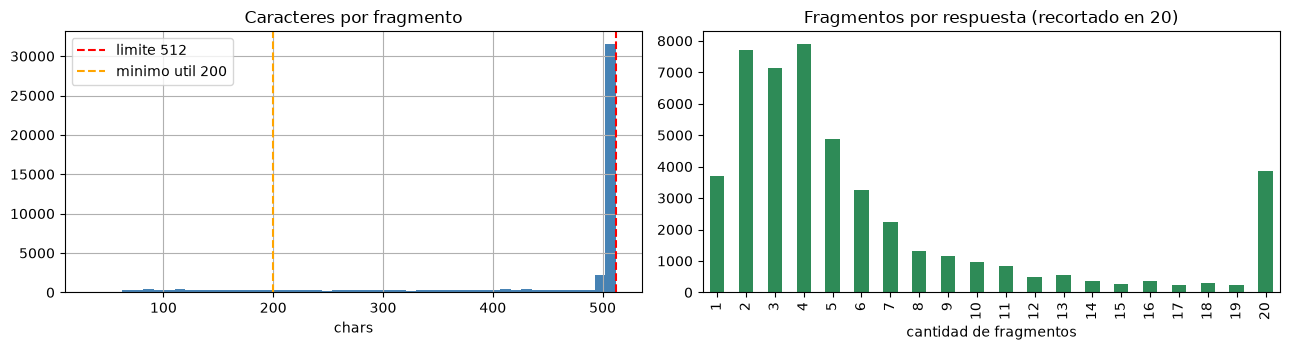

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
chunks["n_chars"].hist(bins=50, ax=ax[0], color="steelblue")
ax[0].axvline(512, color="red", linestyle="--", label="limite 512")
ax[0].axvline(200, color="orange", linestyle="--", label="minimo util 200")
ax[0].set_title("Caracteres por fragmento")
ax[0].set_xlabel("chars")
ax[0].legend()

chunks["n_chunks"].clip(upper=20).value_counts().sort_index().plot(
    kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("Fragmentos por respuesta (recortado en 20)")
ax[1].set_xlabel("cantidad de fragmentos")
plt.tight_layout()
plt.show()

## 2.2 Filtro de aptitud

No todo fragmento sirve para formular una pregunta de examen. Este filtro es
barato y corre **antes** de gastar llamadas a la API.

| Criterio | Se descarta si |
|---|---|
| Muy corto | menos de 200 caracteres: no alcanza para una pregunta con respaldo |
| Sin oracion completa | arrancaba cortado y no quedo nada tras recortar el arranque |
| Casi todo enumeracion | mas del 60% de las lineas son items de lista, **o** la lista viene aplanada en un solo renglon con guiones y porcentajes |
| Sin oracion afirmativa | no contiene ningun verbo que sostenga una afirmacion |
| Boilerplate del HPO | es el texto fijo del Human Phenotype Ontology mas una tabla de porcentajes, sin afirmacion medica |
| Generico | `answer_is_generic`: respuestas de relleno repetidas en el corpus |

El de "arranca cortado" es el que mas importa: con solape de 64 caracteres, la
mayoria de los fragmentos intermedios empieza a mitad de oracion, y una pregunta
construida sobre uno de ellos sale sin sujeto o directamente mal.

Pero descartarlos sin mas seria un desperdicio: son mas de la mitad del corpus y
su contenido es legitimo, solo les sobra el arranque. **Antes de descartar se
intenta recuperarlos** recortando hasta la primera oracion completa. Solo si lo
que queda sigue siendo demasiado corto se descarta el fragmento.

El mismo problema aparece **al final**: el 78% de los fragmentos termina a mitad
de frase. Un final colgando -"...downturned corners of the mouth, and a"- es peor
que un arranque cortado, porque invita al modelo a completar de su propio
conocimiento lo que el fragmento no llego a decir. Tambien se recorta.

### Lo que este filtro no puede ver

Los criterios son **sintacticos**: descartan lo obviamente inservible, no
seleccionan lo bueno. No miran si el fragmento contiene un hecho concreto sobre
el que se pueda preguntar.

Revisando dos muestras de 12 fragmentos a mano, el residuo que queda es de un
solo tipo: **texto institucional generico**, sobre todo sobre ensayos clinicos
("Patients who take part in a clinical trial may receive the standard treatment
or be among the first to receive a new treatment"). Es prosa correcta, con verbos
y sin listas, asi que ningun criterio sintactico lo distingue de contenido
medico real. Pero no afirma nada sobre ninguna enfermedad.

Filtrarlo por palabras clave descartaria tambien fragmentos buenos que solo
*mencionan* un ensayo clinico. Asi que se deja para la seccion 2.4, donde el
modelo puede responder `{"descartar": true}` ante un fragmento del que no se
puede extraer una pregunta con respuesta concreta. **Ese es el proposito de esa
salida**, y conviene medir cuantas veces se usa: es la tasa real de fragmentos
no aptos que el filtro sintactico deja pasar.

In [5]:
MIN_CHARS = 200
MAX_RATIO_LISTA = 0.60

# Verbos que sostienen una afirmacion en el ingles del corpus. No se busca un
# analisis gramatical: alcanza con distinguir una oracion de una lista de
# sintagmas nominales.
VERBOS = re.compile(
    r"\b(?:is|are|was|were|be|been|has|have|had|can|may|might|will|would|should|"
    r"causes?|caused|includes?|occurs?|affects?|results?|leads?|means?|refers?|"
    r"happens?|develops?|produces?|involves?|requires?|helps?|prevents?|treats?)\b",
    re.IGNORECASE,
)
# El Human Phenotype Ontology aporta un bloque de texto fijo que explica que es
# la HPO y luego vuelca una tabla de sintomas con porcentajes. Es identificable
# por su literal y no contiene una afirmacion medica sobre la que preguntar.
BOILERPLATE_HPO = re.compile(
    r"Human Phenotype Ontology|Signs and Symptoms Approximate number of patients|"
    r"MedlinePlus Medical Dictionary to look up|comes from Orphanet|"
    # la cola del mismo bloque, que cae en el fragmento siguiente y ya no
    # menciona la HPO: explica como leer las frecuencias, no la enfermedad
    r"frequencies are based on a specific study|"
    r"no information on frequency is available|"
    r"frequency of \d+/\d+ means|"
    r"frequency may also be listed as a fraction",
    re.IGNORECASE,
)
INICIO_LISTA = re.compile(r"^\s*(?:[-*\u2022\u00b7]|\(?\d+[.)]|[a-z][.)])\s+")


SEPARADOR_ITEM = re.compile(r"\s-\s")
PORCENTAJE = re.compile(r"\d+(?:[.,]\d+)?%")


def es_lista_aplanada(texto):
    """Detecta listas que el corpus trae en una sola linea.

    `ratio_lineas_lista` cuenta lineas que empiezan con vinieta, pero muchas
    tablas del corpus vienen aplanadas en un solo renglon con guiones o
    porcentajes intercalados: "Arrhythmia 7.5% Absent eyebrow - Bradycardia -
    Fair hair - ...". No hay prosa sobre la que preguntar.
    """
    items = len(SEPARADOR_ITEM.findall(texto)) + len(PORCENTAJE.findall(texto))
    palabras = max(len(texto.split()), 1)
    return items >= 5 and items / palabras > 0.06


def ratio_lineas_lista(texto):
    lineas = [l for l in texto.splitlines() if l.strip()]
    if not lineas:
        return 1.0
    return sum(bool(INICIO_LISTA.match(l)) for l in lineas) / len(lineas)


def arranca_cortado(texto):
    """Un fragmento que no empieza una oracion nueva.

    Dos casos: empieza en minuscula (continua la oracion anterior), o empieza
    con puntuacion, que pasa cuando el corte parte una palabra con guion
    ("-tendinous") o cae dentro de un parentesis.
    """
    t = texto.lstrip()
    return (not t) or t[0].islower() or t[0] in "-–—,;:)"


FIN_ORACION = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9])")


def recortar_al_inicio_de_oracion(texto):
    """Devuelve el texto desde la primera oracion completa.

    Los fragmentos intermedios arrancan a mitad de frase por el solape. En vez
    de tirarlos, se les quita el arranque incompleto: lo que queda es texto
    valido y suele ser la mayor parte del fragmento.
    """
    t = texto.lstrip()
    if not arranca_cortado(t):      # misma condicion que decide el rescate
        return t
    corte = FIN_ORACION.search(t)
    return t[corte.end():] if corte else ""


CIERRES = (".", "!", "?")


def termina_en_oracion(texto):
    """True si el fragmento cierra una oracion, admitiendo comillas o parentesis."""
    t = texto.rstrip().rstrip("'" + chr(34) + ")]")
    return bool(t) and t[-1] in CIERRES


def recortar_al_final_de_oracion(texto):
    """Devuelve el texto hasta la ultima oracion completa.

    El troceado por caracteres corta a mitad de frase: 78% de los fragmentos
    terminaba asi. Un final colgando ("...downturned corners of the mouth, and
    a") invita al modelo a completar de su propio conocimiento lo que el
    fragmento no dice, que es justo lo que hay que evitar.
    """
    t = texto.rstrip()
    if not t or termina_en_oracion(t):
        return t
    # ultimo signo de puntuacion que cierra oracion, sin depender de escapes
    posiciones = [t.rfind(c) for c in (".", "!", "?")]
    ultimo = max(posiciones)
    return t[:ultimo + 1] if ultimo > 0 else ""


rescatables = chunks["chunk_text"].map(arranca_cortado)
chunks["chunk_text"] = np.where(
    rescatables,
    chunks["chunk_text"].map(recortar_al_inicio_de_oracion),
    chunks["chunk_text"].str.lstrip(),
)
# y ahora el final, que el troceado tambien deja colgando
cortados_al_final = ~chunks["chunk_text"].map(termina_en_oracion)
chunks["chunk_text"] = chunks["chunk_text"].map(recortar_al_final_de_oracion)
chunks["n_chars"] = chunks["chunk_text"].str.len()
chunks["fue_recortado"] = (rescatables | cortados_al_final) & chunks["n_chars"].gt(0)

perdidos = int((rescatables & chunks["chunk_text"].str.len().eq(0)).sum())
print(f"fragmentos que arrancaban cortados : {int(rescatables.sum()):,}")
print(f"  recuperados recortando           : {int(chunks['fue_recortado'].sum()):,}")
print(f"  sin ninguna oracion completa     : {perdidos:,}")
print()
print(f"fragmentos que terminaban cortados : {int(cortados_al_final.sum()):,}")
print(f"caracteres de media tras recortar  : {chunks['n_chars'].mean():.0f} "
      f"(antes del recorte de final: 380)")



motivos = pd.DataFrame({
    "muy_corto"      : chunks["n_chars"] < MIN_CHARS,
    "sin_oracion_completa": chunks["n_chars"] == 0,
    "casi_todo_lista": (chunks["chunk_text"].map(ratio_lineas_lista) > MAX_RATIO_LISTA)
                       | chunks["chunk_text"].map(es_lista_aplanada),
    "sin_verbo"      : ~chunks["chunk_text"].str.contains(VERBOS, regex=True),
    "boilerplate_hpo": chunks["chunk_text"].str.contains(BOILERPLATE_HPO, regex=True),
    "generico"       : chunks["answer_is_generic"].astype(bool),
})

resumen = pd.DataFrame({
    "descartados por este criterio": motivos.sum(),
    "% del total": (motivos.mean() * 100).round(1),
}).sort_values("descartados por este criterio", ascending=False)
print(resumen.to_string())

descartar = motivos.any(axis=1)
print(f"\nfragmentos totales : {len(chunks):,}")
print(f"descartados        : {descartar.sum():,} ({descartar.mean() * 100:.1f}%)")
print(f"APTOS              : {(~descartar).sum():,}")

fragmentos que arrancaban cortados : 28,124
  recuperados recortando           : 38,293
  sin ninguna oracion completa     : 3,393

fragmentos que terminaban cortados : 35,130
caracteres de media tras recortar  : 308 (antes del recorte de final: 380)


                      descartados por este criterio  % del total
muy_corto                                     11359         23.8
boilerplate_hpo                                7888         16.5
casi_todo_lista                                6440         13.5
sin_verbo                                      6413         13.4
sin_oracion_completa                           4887         10.2
generico                                         55          0.1

fragmentos totales : 47,771
descartados        : 19,477 (40.8%)
APTOS              : 28,294


In [6]:
# Muestra de descartes, para comprobar que el filtro no se lleva material bueno
for criterio in motivos.columns:
    solo_este = motivos[criterio] & ~motivos.drop(columns=[criterio]).any(axis=1)
    sel = chunks.loc[solo_este]
    print(f"\n=== {criterio} - descartados solo por este motivo: {len(sel):,} ===")
    for texto in sel["chunk_text"].head(2):
        print("   ", " ".join(texto.split())[:150], "...")


=== muy_corto - descartados solo por este motivo: 4,882 ===
    Type IV does not appear to cause cardiomyopathy. ...
    In other conditions, encephaloceles may be associated with intellectual disability; however, most people with Knobloch syndrome have normal intelligen ...

=== sin_oracion_completa - descartados solo por este motivo: 0 ===

=== casi_todo_lista - descartados solo por este motivo: 647 ===
    Genetic Testing Registry: Parkinson disease 7 - Genetic Testing Registry: Parkinson disease 8, autosomal dominant - Genetic Testing Registry: Parkinso ...
    These resources address the diagnosis or management of proopiomelanocortin deficiency: - Eunice Kennedy Shriver National Institute of Child Health and ...

=== sin_verbo - descartados solo por este motivo: 214 ===
    The signals triggered by the FGFR2, FGFR3, and FGF10 genes appear to stimulate cells to form the structures that make up the lacrimal glands, salivary ...
    (after age 25) than those with larger GAA trinucle

In [7]:
aptos = chunks.loc[~descartar].copy().reset_index(drop=True)
aptos.to_parquet(DATA / "chunks.parquet", index=False)

print(f"guardado data/chunks.parquet - {len(aptos):,} fragmentos")
print(f"respuestas representadas: {aptos['question_id'].nunique():,}")
print(f"temas (question_focus)  : {aptos['question_focus'].nunique():,}")
print()
print(aptos["question_type"].value_counts().to_string())

guardado data/chunks.parquet - 28,294 fragmentos
respuestas representadas: 10,196
temas (question_focus)  : 3,794

question_type
information        9380
treatment          5226
genetic changes    3074
exams and tests    2360
symptoms           1488
causes             1467
inheritance        1443
stages              708
susceptibility      702
prevention          699
research            656
frequency           405
outlook             293
considerations      291
complications       101
support groups        1


## 2.3 Muestreo para la API

> **La tabla completa de fragmentos es la base de datos de la aplicacion. El
> subconjunto que pasa por la API existe unicamente para entrenar al modelo.**

De ahi que no haga falta generar preguntas para todos los fragmentos. Unos pocos
miles alcanzan de sobra para LoRA, y el resto queda cubierto por el modelo afinado
cuando un usuario pida ese tema. Precisamente eso es lo que justifica haber
entrenado: si se generaran todas por API, bastaria una tabla y el modelo sobraria.

El muestreo es **estratificado por `question_type`** para que el modelo vea todos
los tipos de pregunta, con dos cuidados:

- un **tope** por estrato, para que `information` -el mas numeroso- no domine;
- un **minimo** por estrato, para que los tipos raros no desaparezcan.

`support groups` tiene un solo fragmento en todo el corpus, asi que ningun
esquema proporcional lo conservaria. El minimo lo resuelve.

In [8]:
OBJETIVO = 6000        # fragmentos que pasan por la API
MIN_POR_TIPO = 60      # piso para que los tipos raros sobrevivan
TOPE_POR_TIPO = 1200   # techo para que `information` no domine

conteo = aptos["question_type"].value_counts()
cuota = {}
for tipo, disponibles in conteo.items():
    proporcional = int(round(OBJETIVO * disponibles / len(aptos)))
    objetivo_tipo = max(min(MIN_POR_TIPO, disponibles), min(proporcional, TOPE_POR_TIPO))
    cuota[tipo] = int(min(disponibles, objetivo_tipo))

reparto = pd.DataFrame({
    "disponibles" : conteo,
    "proporcional": (conteo / len(aptos) * OBJETIVO).round(0).astype(int),
    "cuota final" : pd.Series(cuota),
})
reparto["% del corpus"]    = (reparto["disponibles"] / len(aptos) * 100).round(1)
reparto["% de la muestra"] = (reparto["cuota final"] / reparto["cuota final"].sum() * 100).round(1)
print(reparto.to_string())
print(f"\ntotal a generar: {reparto['cuota final'].sum():,}")

                 disponibles  proporcional  cuota final  % del corpus  % de la muestra
information             9380          1989         1200          33.2             22.9
treatment               5226          1108         1108          18.5             21.1
genetic changes         3074           652          652          10.9             12.4
exams and tests         2360           500          500           8.3              9.5
symptoms                1488           316          316           5.3              6.0
causes                  1467           311          311           5.2              5.9
inheritance             1443           306          306           5.1              5.8
stages                   708           150          150           2.5              2.9
susceptibility           702           149          149           2.5              2.8
prevention               699           148          148           2.5              2.8
research                 656           139 

### Diversidad de temas dentro de cada estrato

Un riesgo del muestreo aleatorio simple: que caigan varios fragmentos de la misma
respuesta y el modelo vea el mismo tema repetido. Se evita tomando **un fragmento
por respuesta** mientras se pueda, y completando con un segundo solo si la cuota
no se llena.

In [9]:
seleccion = []

for tipo, n in cuota.items():
    pool = aptos[aptos["question_type"] == tipo]
    # primera pasada: como maximo un fragmento por respuesta
    primera = (pool.sample(frac=1, random_state=SEMILLA)
                   .drop_duplicates(subset="question_id", keep="first"))
    tomados = primera.head(n)
    if len(tomados) < n:                       # completar con los que quedaron
        resto = pool.drop(index=tomados.index)
        faltan = min(n - len(tomados), len(resto))
        if faltan > 0:
            tomados = pd.concat([tomados, resto.sample(n=faltan, random_state=SEMILLA)])
    seleccion.append(tomados)

muestra = (pd.concat(seleccion)
             .sample(frac=1, random_state=SEMILLA)
             .reset_index(drop=True))
muestra.to_parquet(DATA / "muestra_api.parquet", index=False)

pct_div = muestra["question_id"].nunique() / len(muestra) * 100
print(f"muestra para la API : {len(muestra):,} fragmentos")
print(f"respuestas distintas: {muestra['question_id'].nunique():,} ({pct_div:.0f}% - cuanto mas alto, mas diverso)")
print(f"temas distintos     : {muestra['question_focus'].nunique():,}")
print(f"caracteres de media : {muestra['n_chars'].mean():.0f}")
print()
print(muestra["question_type"].value_counts().to_string())

muestra para la API : 5,250 fragmentos
respuestas distintas: 5,148 (98% - cuanto mas alto, mas diverso)
temas distintos     : 2,471
caracteres de media : 389

question_type
information        1200
treatment          1108
genetic changes     652
exams and tests     500
symptoms            316
causes              311
inheritance         306
stages              150
susceptibility      149
prevention          148
research            139
frequency            86
outlook              62
considerations       62
complications        60
support groups        1


In [10]:
# Costo estimado de la seccion 2.4, antes de gastar nada
TOK_ENTRADA = muestra["n_chars"].mean() / 4 + 220   # fragmento + instruccion
TOK_SALIDA = 160
PRECIO_IN, PRECIO_OUT = 0.15 / 1e6, 0.60 / 1e6      # gpt-4o-mini, USD por token

costo = len(muestra) * (TOK_ENTRADA * PRECIO_IN + TOK_SALIDA * PRECIO_OUT)
print(f"tokens de entrada por llamada (estimado): {TOK_ENTRADA:.0f}")
print(f"llamadas                                : {len(muestra):,}")
print(f"COSTO ESTIMADO                          : USD {costo:.2f}")

tokens de entrada por llamada (estimado): 317
llamadas                                : 5,250
COSTO ESTIMADO                          : USD 0.75


## Estado

| Archivo | Contenido |
|---|---|
| `data/chunks.parquet` | fragmentos aptos - **la base de datos de la aplicacion** |
| `data/muestra_api.parquet` | los que pasan por la API en la seccion 2.4 |

Siguiente paso: la generacion con el LLM. Conviene correrla primero sobre unos
200 fragmentos y revisar las preguntas a mano antes de escalar a la muestra
completa, porque el prompt define la calidad de todo el set de entrenamiento.

## 2.4 Generacion con el LLM

Un llamado por fragmento. El punto que resuelve el problema de las respuestas
larguisimas: **la respuesta correcta no es el fragmento, sino una afirmacion
corta extraida de el**, con tope de 15 palabras.

### Piloto antes de escalar

Esta seccion corre primero sobre **200 fragmentos**, no sobre los 5,250. El
prompt define la calidad de todo el set de entrenamiento, y ajustarlo despues de
gastar la muestra completa seria tirar el trabajo. El piloto cuesta unos 3
centavos y responde tres preguntas que el filtro sintactico dejo abiertas:

| Que se mide | Por que importa |
|---|---|
| **tasa de `descartar`** | es la medicion real de cuantos fragmentos no aptos dejo pasar el filtro de §2.2. Si supera el 5%, el filtro se queda corto |
| tasa de JSON valido | si el modelo maestro ya falla el formato, el prompt esta mal |
| tasa de rechazo por cada filtro de calidad | si un filtro descarta el 40%, el problema es el prompt, no el filtro |

Ademas hay que **leer preguntas a mano**. Ninguna metrica automatica detecta una
pregunta que tiene dos respuestas correctas o que esta mal planteada.

In [11]:
import json, os, random, time
from concurrent.futures import ThreadPoolExecutor, as_completed

from openai import OpenAI

MODELO_API = "gpt-4o-mini"
N_PILOTO = 200
HILOS = 12
TEMPERATURA = 0.7

from dotenv import load_dotenv
load_dotenv("../.env")                 # la clave vive fuera del notebook
client = OpenAI()                      # lee OPENAI_API_KEY del entorno
SALIDA = DATA / "mcq_piloto_v2.jsonl"

### El prompt

Cinco reglas, cada una atada a un fallo concreto que se observo:

1. **Respuesta corta y longitudes parejas.** Sin esto las cuatro opciones serian
   parrafos de 400 caracteres. Y si la correcta es siempre la mas larga, se
   acierta sin saber el tema.
2. **Distractores inequivocamente falsos.** En la prueba de humo el modelo puso
   "ansiedad y estres" como distractor de una pregunta sobre cefalea tensional,
   cuando el fragmento dice que estan relacionadas. Un distractor cierto arruina
   la pregunta.
3. **Pregunta autocontenida.** "Segun el fragmento, que..." no se sostiene en un
   examen, donde el estudiante no ve el fragmento.
4. **Espanol neutro latinoamericano.** Sin fijarlo, el modelo mezcla registros.
5. **`descartar: true`.** La valvula de escape para los fragmentos que el filtro
   sintactico no supo rechazar. Es preferible perder un fragmento a envenenar el
   set de entrenamiento con una pregunta mala, porque el modelo aprenderia a
   imitarla.

In [12]:
PROMPT = """Eres un docente de medicina que redacta preguntas de examen.

PASO 1 - Decide si el FRAGMENTO sirve.
Un fragmento sirve solo si afirma algo concreto sobre una enfermedad, un
sintoma, un tratamiento o un mecanismo biologico. NO sirve si habla de sitios
web, registros, bases de datos, folletos, a quien esta dirigido un recurso,
ensayos clinicos en general, o si solo recomienda consultar a un profesional.
Ante la duda, descartalo: es preferible perder un fragmento a escribir una
pregunta que no es de medicina.

PASO 2 - Si sirve, escribe UNA pregunta de opcion multiple.

Reglas obligatorias:
- La respuesta correcta debe estar explicitamente respaldada por el fragmento.
- Las tres opciones incorrectas deben ser plausibles para alguien que no estudio
  el tema, pero INEQUIVOCAMENTE FALSAS segun el fragmento. Si el fragmento dice
  que algo es cierto, no puede aparecer como opcion incorrecta.
- Las cuatro opciones deben ser MUTUAMENTE EXCLUYENTES y claramente distintas.
  Nunca escribas dos opciones que signifiquen lo mismo con otras palabras
  ("profesionales de la salud" y "proveedores de salud" son la misma opcion).
- Las CUATRO opciones: maximo 15 palabras cada una y de longitud similar.
- Debe haber UNA SOLA respuesta correcta.
- La pregunta debe entenderse sola, sin ver el fragmento. Prohibido escribir
  "segun el fragmento", "el texto menciona" o "de acuerdo al documento".
- Prefiere preguntas de dificultad MEDIA: que exijan relacionar dos datos del
  fragmento o distinguir entre conceptos parecidos, en vez de repetir un dato
  literal. Una pregunta cuya respuesta se copia tal cual de una sola frase es
  demasiado facil.
- Traduce los terminos medicos al espanol. Si el termino tecnico en ingles es
  el de uso habitual, ponlo entre parentesis despues del espanol.
- Escribe en espanol neutro latinoamericano. Si usas verbos en imperativo o
  segunda persona, usa tuteo y no voseo: "elige" y no "elegi".
- No inventes datos que no esten en el fragmento.

Responde SIEMPRE con un JSON que empiece por el campo "apto".

Si el fragmento NO sirve:
{"apto": false, "motivo": "por que no sirve, en pocas palabras"}

Si SI sirve:
{"apto": true, "pregunta": "...", "correcta": "...",
 "incorrectas": ["...", "...", "..."], "dificultad": "facil|media|dificil"}"""

print(PROMPT[:400], "...")

Eres un docente de medicina que redacta preguntas de examen.

PASO 1 - Decide si el FRAGMENTO sirve.
Un fragmento sirve solo si afirma algo concreto sobre una enfermedad, un
sintoma, un tratamiento o un mecanismo biologico. NO sirve si habla de sitios
web, registros, bases de datos, folletos, a quien esta dirigido un recurso,
ensayos clinicos en general, o si solo recomienda consultar a un profesi ...


### Generacion

Concurrencia con hilos, reintentos con espera creciente, y guardado incremental
a JSONL para poder reanudar si se corta. Cada linea del JSONL conserva el
`chunk_uid` y la respuesta cruda del modelo: si mas adelante hay que rehacer el
parseo o los filtros, no hace falta volver a pagar.

In [13]:
def pedir_una(fila, reintentos=3):
    """Genera la pregunta de un fragmento. Devuelve el registro crudo."""
    mensajes = [
        {"role": "system", "content": PROMPT},
        {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]},
    ]
    for intento in range(reintentos):
        try:
            t0 = time.time()
            r = client.chat.completions.create(
                model=MODELO_API, messages=mensajes,
                temperature=TEMPERATURA, max_tokens=320,
            )
            return {
                "chunk_uid": fila["chunk_uid"],
                "crudo": r.choices[0].message.content,
                "tok_in": r.usage.prompt_tokens,
                "tok_out": r.usage.completion_tokens,
                "segundos": round(time.time() - t0, 2),
                "error": None,
            }
        except Exception as exc:
            if intento == reintentos - 1:
                return {"chunk_uid": fila["chunk_uid"], "crudo": None,
                        "tok_in": 0, "tok_out": 0, "segundos": 0,
                        "error": f"{type(exc).__name__}: {exc}"}
            time.sleep(2 ** intento)


def generar(df, salida):
    """Genera para todo el DataFrame, saltando lo ya hecho en `salida`."""
    hechos = set()
    if salida.exists():
        with open(salida, encoding="utf-8") as fh:
            # un registro con error NO cuenta como hecho: se reintenta
            hechos = {r["chunk_uid"] for r in map(json.loads, filter(str.strip, fh))
                      if not r.get("error")}
        print(f"reanudando: {len(hechos):,} ya generados")

    pendientes = df[~df["chunk_uid"].isin(hechos)].to_dict("records")
    if not pendientes:
        print("nada pendiente")
        return

    t0 = time.time()
    with open(salida, "a", encoding="utf-8") as fh, ThreadPoolExecutor(HILOS) as pool:
        futuros = {pool.submit(pedir_una, f): f for f in pendientes}
        for i, fut in enumerate(as_completed(futuros), 1):
            fh.write(json.dumps(fut.result(), ensure_ascii=False) + "\n")
            fh.flush()
            if i % 50 == 0 or i == len(pendientes):
                print(f"  {i:,}/{len(pendientes):,}  ({time.time()-t0:.0f}s)", flush=True)


# Reparto proporcional por tipo, sin `apply`: en pandas 3 la columna de
# agrupacion no llega al DataFrame que recibe la funcion.
partes = []
for tipo, grupo in muestra.groupby("question_type"):
    n = max(1, round(N_PILOTO * len(grupo) / len(muestra)))
    partes.append(grupo.head(n))
piloto = pd.concat(partes).reset_index(drop=True)
print(f"piloto: {len(piloto)} fragmentos sobre {piloto['question_type'].nunique()} tipos")
generar(piloto, SALIDA)

piloto: 201 fragmentos sobre 16 tipos
reanudando: 201 ya generados
nada pendiente


### Lo que revela el piloto

In [14]:
crudos = [json.loads(l) for l in open(SALIDA, encoding="utf-8")]
print(f"registros: {len(crudos)}")

fallidos = [c for c in crudos if c["error"]]
print(f"errores de API: {len(fallidos)}")

def parsear(texto):
    if not texto:
        return None
    t = texto.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        return json.loads(t)
    except Exception:
        return None

parseados = [(c, parsear(c["crudo"])) for c in crudos if not c["error"]]
json_ok = [(c, d) for c, d in parseados if d is not None]
descartados = [(c, d) for c, d in json_ok if d.get("apto") is False or d.get("descartar")]
generadas = [(c, d) for c, d in json_ok if d.get("pregunta")]

n = len(parseados)
print()
print(f"JSON valido al primer intento : {len(json_ok)}/{n}  ({len(json_ok)/n*100:.1f}%)")
print(f"el modelo DESCARTO el fragmento: {len(descartados)}/{n}  ({len(descartados)/n*100:.1f}%)")
print(f"preguntas generadas            : {len(generadas)}")
print()
coste = sum(c["tok_in"] for c in crudos) * 0.15/1e6 + sum(c["tok_out"] for c in crudos) * 0.60/1e6
print(f"tokens: {sum(c['tok_in'] for c in crudos):,} entrada / {sum(c['tok_out'] for c in crudos):,} salida")
print(f"costo del piloto: USD {coste:.3f}  ->  extrapolado a {len(muestra):,}: USD {coste/len(crudos)*len(muestra):.2f}")

registros: 201
errores de API: 0

JSON valido al primer intento : 201/201  (100.0%)
el modelo DESCARTO el fragmento: 12/201  (6.0%)
preguntas generadas            : 189

tokens: 134,818 entrada / 16,875 salida
costo del piloto: USD 0.030  ->  extrapolado a 5,250: USD 0.79


**La cifra que hay que mirar es la tasa de `descartar`.** Es la medicion
directa de cuantos fragmentos no aptos dejo pasar el filtro sintactico de §2.2.
Por encima del 5% conviene volver sobre el filtro antes de escalar.

In [15]:
from collections import Counter
motivos = Counter(d.get("motivo", "(sin motivo)")[:70] for _, d in descartados)
print("por que descarto el modelo:")
for m, k in motivos.most_common(10):
    print(f"  {k:>3}  {m}")

print()
tipos = pd.Series([c["chunk_uid"] for c, _ in descartados])
mapa = muestra.set_index("chunk_uid")["question_type"]
print("descartes por tipo de pregunta:")
print(tipos.map(mapa).value_counts().to_string())

por que descarto el modelo:
    1  porque el fragmento no afirma nada concreto sobre una enfermedad, sínt
    1  el fragmento habla de recursos y recomendaciones sobre pruebas genétic
    1  El fragmento habla sobre programas de seguro de salud y no sobre enfer
    1  El fragmento habla sobre investigaciones y no proporciona información 
    1  El fragmento no afirma nada concreto sobre una enfermedad, síntoma, tr
    1  El fragmento no habla de una enfermedad, síntoma o tratamiento específ
    1  El fragmento habla sobre ensayos clínicos en general y no sobre una en
    1  El fragmento no se centra en una enfermedad, síntoma, tratamiento o me
    1  habla de un sitio web y no proporciona información sobre la enfermedad
    1  no contiene información concreta sobre una enfermedad, síntoma, tratam

descartes por tipo de pregunta:
treatment          4
research           3
exams and tests    2
information        1
prevention         1
susceptibility     1


### Revision a mano

Ninguna metrica automatica detecta una pregunta con dos respuestas correctas o
mal planteada. Hay que leerlas.

In [16]:
muestra_texto = muestra.set_index("chunk_uid")["chunk_text"]
random.seed(7)
for c, d in random.sample(generadas, min(10, len(generadas))):
    print("=" * 96)
    print("FRAGMENTO:", " ".join(muestra_texto[c["chunk_uid"]].split())[:230], "...")
    print()
    print("  P:", d["pregunta"], f"   [{d.get('dificultad')}]")
    print("  ->", d["correcta"], "   (correcta)")
    for inc in d["incorrectas"]:
        print("  - ", inc)
    print()

FRAGMENTO: Pustular psoriasis is a rare form of psoriasis that is characterized by widespread pustules and reddish skin. This condition can occur alone or with plaque-type psoriasis. Most cases of pustular psoriasis are thought to be "multif ...

  P: ¿Cuál de los siguientes factores puede desencadenar la psoriasis pustulosa?    [media]
  -> Retiro de corticosteroides    (correcta)
  -  Uso excesivo de corticosteroides
  -  Infecciones virales únicamente
  -  Cambio de dieta repentino

FRAGMENTO: Similar changes in the structure of the DMPK and CNBP genes cause the two forms of myotonic dystrophy. In each case, a segment of DNA is abnormally repeated many times, forming an unstable region in the gene. The mutated gene prod ...

  P: ¿Qué producen las mutaciones en los genes DMPK y CNBP en la distrofia miotónica?    [media]
  -> Una versión expandida del ARN mensajero    (correcta)
  -  Proteínas defectuosas que no funcionan
  -  Una reducción en la producción de proteínas
  -  Un aumen

### Que mostro el piloto, y que se corrigio

Se corrieron **dos versiones del prompt** sobre los mismos 201 fragmentos:

| | v1 | v2 |
|---|---|---|
| JSON valido al primer intento | 100% | 100% |
| **Descarta el fragmento** | **0 (0%)** | **12 (6.0%)** |
| Dificultad: facil / media | 197 / 4 | 2 / 187 |
| Dos opciones muy parecidas | 11.9% | 9.0% |
| Opciones sobre 15 palabras | 0 | 0 |

Con la v1 el modelo **nunca** uso la salida de descarte: ante un fragmento sobre
el publico objetivo de un sitio web genero igual una pregunta, que no es de
medicina. La v2 lo arregla obligandolo a decidir primero, con un campo `apto`
que va antes que nada, y describiendo con ejemplos que **no** es contenido medico.

Ese 6% es el dato que faltaba: **es la proporcion de fragmentos no aptos que el
filtro sintactico de §2.2 deja pasar**. Revisando los 12 descartes a mano, 8 son
correctos (sitios web, seguros medicos, ensayos clinicos, listas de enlaces) y 3
son falsos positivos: fragmentos con contenido medico legitimo que el modelo
descarto dando ademas un motivo que no se corresponde con el texto. Perder un
1.5% de material bueno para atrapar un 4% de malo es un intercambio favorable
cuando hay 28,294 fragmentos disponibles y solo se necesitan 5,250.

La v2 tambien corrige el sesgo de dificultad: la v1 producia preguntas de dato
literal casi siempre. Ninguna de las dos genera preguntas "dificiles"; se acepta
como limitacion.

Defectos residuales, todos filtrables en §2.5: un **9%** con dos opciones
demasiado parecidas y un **2.1%** que se refiere al fragmento ("la prueba de
heces mencionada"), que el estudiante no ve.

## 2.4.b Generacion sobre la muestra completa

Con el prompt validado se corre sobre los 5,250 fragmentos. Mismo codigo y misma
funcion `generar`: el JSONL se escribe incrementalmente y la corrida se reanuda
sola si se interrumpe.

In [17]:
SALIDA_COMPLETA = DATA / "mcq_crudo.jsonl"
generar(muestra, SALIDA_COMPLETA)

reanudando: 5,250 ya generados
nada pendiente


In [18]:
crudos_full = [json.loads(l) for l in open(SALIDA_COMPLETA, encoding="utf-8")]
parseados_full = [(c, parsear(c["crudo"])) for c in crudos_full if not c["error"]]
ok_full = [(c, d) for c, d in parseados_full if d is not None]
desc_full = [(c, d) for c, d in ok_full if d.get("apto") is False]
gen_full = [(c, d) for c, d in ok_full if d.get("pregunta")]

n = len(crudos_full)
print(f"fragmentos procesados : {n:,}")
print(f"errores de API        : {sum(1 for c in crudos_full if c["error"]):,}")
print(f"JSON valido           : {len(ok_full):,} ({len(ok_full)/n*100:.1f}%)")
print(f"descartados por el LLM: {len(desc_full):,} ({len(desc_full)/n*100:.1f}%)")
print(f"PREGUNTAS GENERADAS   : {len(gen_full):,}")
print()
coste = (sum(c["tok_in"] for c in crudos_full) * 0.15 / 1e6
         + sum(c["tok_out"] for c in crudos_full) * 0.60 / 1e6)
print(f"costo real: USD {coste:.2f}")
print()
print(pd.Series([d.get("dificultad") for _, d in gen_full]).value_counts().to_string())

fragmentos procesados : 5,250
errores de API        : 0
JSON valido           : 5,247 (99.9%)
descartados por el LLM: 339 (6.5%)
PREGUNTAS GENERADAS   : 4,908

costo real: USD 0.79

media    4893
facil      15


## 2.5 Filtros de calidad

Los filtros van de mas barato a mas caro. Los primeros ocho son reglas sobre el
texto; el ultimo es un juez que lee el fragmento.

| # | Filtro | Rechaza si |
|---|---|---|
| 1 | estructura | falta un campo, o no hay exactamente 3 incorrectas |
| 2 | opciones distintas | dos opciones coinciden tras normalizar |
| 3 | opciones parecidas | dos opciones comparten mas de la mitad de sus palabras |
| 4 | longitud maxima | alguna opcion supera 15 palabras |
| 5 | longitud pareja | la opcion mas larga mide mas de 2.5 veces la mas corta |
| 6 | distractor en el fragmento | un distractor aparece textualmente en el texto fuente |
| 7 | autocontenida | la pregunta se refiere al fragmento ("la prueba mencionada") |
| 8 | pregunta negativa | pregunta por lo que NO ocurre |
| 9 | duplicada | la misma pregunta ya aparecio |

### Por que cada uno

El **5** corrige el sesgo mas comun de los examenes generados: si la correcta es
siempre la mas larga y detallada, se acierta sin saber el tema. Solo se aplica
cuando alguna opcion supera los 40 caracteres: con opciones cortas el ratio se
dispara sin que haya desequilibrio real.

El **3** descuenta el prefijo comun antes de comparar. Sin ese descuento
rechazaba preguntas bien construidas: cuatro genes distintos ("Mutaciones en el
gen CTNNB1 / APC / BRCA1 / TP53") daban 0.8 de solape por compartir el prefijo,
cuando la estructura paralela es justamente buena practica. Medido sobre las
4,908 preguntas generadas, la version anterior descartaba **220 preguntas
legitimas**.

El **6** es el mas importante para la seguridad de la pregunta. Si un distractor
esta literalmente en el fragmento, es probable que tambien sea cierto, y entonces
la pregunta tiene dos respuestas validas. El juez confirmo que ese fallo existe
en un 5.3% de los casos.

El **8** sale de la revision con el juez: las preguntas del tipo "cual factor NO
influye" exigen que tres opciones sean verdaderas y una falsa, al reves del
diseno habitual. En la muestra evaluada, las dos que aparecieron eran
defectuosas. Son el 1.7% del total, asi que descartarlas cuesta poco y elimina un
patron de riesgo completo.

In [19]:
import re
import unicodedata

MAX_PALABRAS = 15
MAX_RATIO = 2.5
MIN_LARGO_PARA_RATIO = 40   # por debajo, las cuatro caben en un renglon
SOLAPE_MAX = 0.5

DEICTICO = re.compile(
    r"\b(mencionad[oa]s?|citad[oa]s?|el (texto|fragmento|documento|pasaje)|"
    r"seg[uu]n el|el siguiente|indicad[oa]s?)\b", re.IGNORECASE)
# "no" seguido de verbo, no el "no" de un nombre propio ("no involutivo")
NEGATIVA = re.compile(
    r"\bno\s+(influye|afecta|es|son|se|tiene|forma|corresponde|pertenece|"
    r"deber[ia]|puede|causa|produce)\b|\bexcepto\b|\bcual.{0,12}NO\b", re.IGNORECASE)


def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")


def palabras(s):
    return set(re.findall(r"[a-z0-9]+", sin_acentos(s)))


def revisar(d, fragmento):
    """Devuelve la lista de filtros que la pregunta incumple."""
    fallos = []
    inc = d.get("incorrectas") or []

    if not d.get("pregunta") or not d.get("correcta") or len(inc) != 3:
        return ["1_estructura"]

    opciones = [str(d["correcta"])] + [str(x) for x in inc]
    normalizadas = [sin_acentos(o).strip(" .") for o in opciones]

    if len(set(normalizadas)) < 4:
        fallos.append("2_identicas")

    # Antes de comparar se descuenta el prefijo comun a las cuatro opciones. La
    # estructura paralela ("Mutaciones en el gen X") es BUENA practica en
    # examenes: sin este descuento, cuatro genes distintos dan 0.8 de solape
    # porque comparten "mutaciones en el gen", y se rechazaban justo las
    # preguntas mejor construidas.
    comunes = set.intersection(*(palabras(o) for o in opciones))
    distintivas = [palabras(o) - comunes for o in opciones]

    for i in range(4):
        for j in range(i + 1, 4):
            a, b = distintivas[i], distintivas[j]
            if not a or not b:
                fallos.append("3_sin_nada_propio")   # solo el prefijo comun
                break
            if len(a & b) / len(a | b) > SOLAPE_MAX:
                fallos.append("3_parecidas")
                break
        else:
            continue
        break

    if max(len(o.split()) for o in opciones) > MAX_PALABRAS:
        fallos.append("4_muy_larga")

    largos = [len(o) for o in opciones]
    # El ratio solo importa cuando alguna opcion es larga de verdad: con cuatro
    # opciones cortas ("Migrana" contra "Cefalea en racimos") 18/7 da 2.6 y las
    # dos caben en un renglon. El sesgo real es la correcta larga y detallada
    # frente a distractores de una palabra.
    if max(largos) > MIN_LARGO_PARA_RATIO and max(largos) / max(min(largos), 1) > MAX_RATIO:
        fallos.append("5_desparejas")

    frag_norm = sin_acentos(fragmento)
    for x in inc:
        t = sin_acentos(x).strip(" .")
        if len(t) > 12 and t in frag_norm:
            fallos.append("6_distractor_en_fragmento")
            break

    if DEICTICO.search(d["pregunta"]):
        fallos.append("7_no_autocontenida")

    if NEGATIVA.search(d["pregunta"]):
        fallos.append("8_negativa")

    return fallos

In [20]:
fragmentos = muestra.set_index("chunk_uid")["chunk_text"]

filas, motivos_todos = [], []
vistas = set()
for c, d in gen_full:
    fallos = revisar(d, fragmentos[c["chunk_uid"]])
    clave = sin_acentos(d.get("pregunta", "")).strip()
    if clave in vistas:
        fallos = fallos + ["9_duplicada"]
    else:
        vistas.add(clave)
    motivos_todos.extend(fallos)
    if not fallos:
        filas.append({
            "chunk_uid"     : c["chunk_uid"],
            "pregunta"      : d["pregunta"],
            "correcta"      : d["correcta"],
            "incorrectas"   : list(d["incorrectas"]),
            "dificultad"    : d.get("dificultad", "media"),
        })

from collections import Counter
conteo = Counter(motivos_todos)
print(f"preguntas evaluadas : {len(gen_full):,}")
print()
for k, v in sorted(conteo.items()):
    print(f"  {k:<28} {v:>5,}  ({v/len(gen_full)*100:.1f}%)")
print()
print(f"  APROBADAS                    {len(filas):>5,}  ({len(filas)/len(gen_full)*100:.1f}%)")

preguntas evaluadas : 4,908

  1_estructura                     5  (0.1%)
  3_parecidas                    212  (4.3%)
  3_sin_nada_propio                5  (0.1%)
  4_muy_larga                      1  (0.0%)
  5_desparejas                    59  (1.2%)
  6_distractor_en_fragmento        7  (0.1%)
  7_no_autocontenida              63  (1.3%)
  8_negativa                      27  (0.6%)
  9_duplicada                     66  (1.3%)

  APROBADAS                    4,483  (91.3%)


In [21]:
mcq = pd.DataFrame(filas)
meta = muestra.set_index("chunk_uid")[
    ["chunk_text", "question_id", "document_id", "question_focus",
     "question_type", "document_source", "document_url"]]
mcq = mcq.join(meta, on="chunk_uid")

print(f"dataset de preguntas: {len(mcq):,}")
print(f"  documentos distintos : {mcq['document_id'].nunique():,}")
print(f"  temas distintos      : {mcq['question_focus'].nunique():,}")
print()
print(mcq["question_type"].value_counts().to_string())
mcq.head(3)[["pregunta", "correcta", "dificultad"]]

dataset de preguntas: 4,483
  documentos distintos : 1,702
  temas distintos      : 2,330

question_type
information        1079
treatment           927
genetic changes     607
exams and tests     406
symptoms            289
causes              280
inheritance         228
susceptibility      131
stages              123
prevention          117
research             70
frequency            66
complications        57
outlook              55
considerations       47
support groups        1


,pregunta,correcta,dificultad
0,¿Cuál es la función principal del factor de crecimiento nervioso beta (NGF)?,Estimular el crecimiento y maduración de las neuronas.,media
1,¿Qué es la metástasis en el cáncer?,Es el proceso de diseminación a otras partes del cuerpo.,media
2,¿Cómo se denomina la parálisis de la mitad inferior del cuerpo?,Paraplejía,media


## 2.6 Splits sin fuga

Los fragmentos tienen 64 caracteres de solape, asi que dos fragmentos del mismo
documento comparten texto. Si uno cae en entrenamiento y el otro en prueba, la
evaluacion mide memorizacion en vez de generalizacion.

Por eso el split **agrupa por `document_id`**: todos los fragmentos de un mismo
documento van al mismo lado. Se usa `GroupShuffleSplit`, que es exactamente para
esto.

In [22]:
from sklearn.model_selection import GroupShuffleSplit

def partir(df, test_size, semilla=SEMILLA):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=semilla)
    izq, der = next(gss.split(df, groups=df["document_id"]))
    return df.iloc[izq].reset_index(drop=True), df.iloc[der].reset_index(drop=True)

train_val, test = partir(mcq, test_size=0.10)
train, val = partir(train_val, test_size=0.111)

for nombre, parte in [("train", train), ("val", val), ("test", test)]:
    parte.to_parquet(DATA / f"mcq_{nombre}.parquet", index=False)
    print(f"{nombre:<6} {len(parte):>5,} preguntas | {parte['document_id'].nunique():>4,} documentos")

# verificacion: ningun documento aparece en dos splits
docs = {n: set(p["document_id"]) for n, p in
        [("train", train), ("val", val), ("test", test)]}
print()
print("fuga entre splits (documentos compartidos):")
print(f"  train-val : {len(docs['train'] & docs['val'])}")
print(f"  train-test: {len(docs['train'] & docs['test'])}")
print(f"  val-test  : {len(docs['val'] & docs['test'])}")

train  3,614 preguntas | 1,361 documentos
val      433 preguntas |  170 documentos
test     436 preguntas |  171 documentos

fuga entre splits (documentos compartidos):
  train-val : 0
  train-test: 0
  val-test  : 0


## 2.7 Nombres en espanol para la interfaz

`question_type` y `question_focus` estan en ingles porque vienen del corpus. La
aplicacion los usa como filtros internos, pero el estudiante no puede ver un
desplegable que diga "exams and tests" o "Sleep Apnea" en una app en espanol.

Se agregan dos columnas de presentacion a `chunks.parquet`:

- **`tipo_es`**: los 16 tipos, traducidos a mano. No hace falta la API.
- **`tema_es`**: los temas, traducidos en lotes con el modelo. Se hace una sola
  vez y queda guardado; la app carga una tabla lista y no traduce en tiempo real.

Ademas resuelve la busqueda: escribir "asma" tiene que encontrar los fragmentos
de `Asthma`.

In [23]:
TIPOS_ES = {
    "information"     : "Informacion general",
    "symptoms"        : "Sintomas",
    "treatment"       : "Tratamiento",
    "genetic changes" : "Alteraciones geneticas",
    "inheritance"     : "Herencia",
    "exams and tests" : "Examenes y pruebas",
    "causes"          : "Causas",
    "frequency"       : "Frecuencia",
    "outlook"         : "Pronostico",
    "research"        : "Investigacion",
    "susceptibility"  : "Factores de riesgo",
    "prevention"      : "Prevencion",
    "considerations"  : "Consideraciones",
    "stages"          : "Estadios",
    "complications"   : "Complicaciones",
    "support groups"  : "Grupos de apoyo",
}
faltan = set(aptos["question_type"]) - set(TIPOS_ES)
print("tipos sin traducir:", faltan or "ninguno")

tipos sin traducir: ninguno


In [24]:
TRAD_PROMPT = (
    "Traduce al espanol cada nombre de enfermedad o tema medico. Usa el nombre "
    "con el que se conoce en medicina en espanol; si es un epónimo o una sigla "
    "establecida, consérvala. Responde SOLO un JSON array de strings, en el "
    "mismo orden y con la misma cantidad de elementos que recibiste."
)

def traducir_lote(lote):
    r = client.chat.completions.create(
        model=MODELO_API, temperature=0,
        messages=[{"role": "system", "content": TRAD_PROMPT},
                  {"role": "user", "content": json.dumps(lote, ensure_ascii=False)}])
    t = r.choices[0].message.content.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    salida = json.loads(t)
    return salida if len(salida) == len(lote) else lote   # ante duda, el original


temas = sorted(aptos["question_focus"].dropna().astype(str).unique())
print(f"temas a traducir: {len(temas):,}")

CACHE = DATA / "temas_es.json"
traducciones = json.load(open(CACHE, encoding="utf-8")) if CACHE.exists() else {}
pendientes = [t for t in temas if t not in traducciones]
print(f"pendientes: {len(pendientes):,}")

LOTE = 40
lotes = [pendientes[i:i + LOTE] for i in range(0, len(pendientes), LOTE)]
if lotes:
    with ThreadPoolExecutor(8) as pool:
        futs = {pool.submit(traducir_lote, l): l for l in lotes}
        for i, fut in enumerate(as_completed(futs), 1):
            original = futs[fut]
            try:
                for o, t in zip(original, fut.result()):
                    traducciones[o] = t
            except Exception:
                for o in original:
                    traducciones[o] = o
            if i % 20 == 0 or i == len(lotes):
                print(f"  lote {i}/{len(lotes)}", flush=True)
    json.dump(traducciones, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=1)

print(f"traducidos: {len(traducciones):,}")

temas a traducir: 3,794
pendientes: 0
traducidos: 3,794


In [25]:
aptos["tipo_es"] = aptos["question_type"].map(TIPOS_ES).fillna(aptos["question_type"])
aptos["tema_es"] = aptos["question_focus"].astype(str).map(traducciones).fillna(aptos["question_focus"])
aptos.to_parquet(DATA / "chunks.parquet", index=False)

print("chunks.parquet actualizado con tipo_es y tema_es")
print()
print(aptos[["question_focus", "tema_es"]].drop_duplicates().head(12).to_string(index=False))

chunks.parquet actualizado con tipo_es y tema_es

                                                  question_focus                                                                tema_es
                                    keratoderma with woolly hair                                       queratodermia con cabello lanoso
                                               Knobloch syndrome                                                   Síndrome de Knobloch
                                                        coloboma                                                               coloboma
                         lacrimo-auriculo-dento-digital syndrome                                síndrome lacrimo-auriculo-dento-digital
                                   spinocerebellar ataxia type 3                                         ataxia espinocerebelosa tipo 3
                                                   pilomatricoma                                                          pilomatricom

## Estado final del notebook 02

| Archivo | Contenido |
|---|---|
| `data/chunks.parquet` | fragmentos aptos, con nombres en espanol - **la BD de la app** |
| `data/mcq_train.parquet` | preguntas para entrenar |
| `data/mcq_val.parquet` | para vigilar el sobreajuste |
| `data/mcq_test.parquet` | para la comparacion base contra afinado |
| `data/mcq_crudo.jsonl` | respuestas crudas del modelo, por si hay que rehacer el parseo sin volver a pagar |

Siguiente: el notebook 03, que se corre en Colab.